# House Price Prediction
Name : Piyush Adlakha <br>
Roll no : 2K24CSUN01120 <br>
Class : CSE-4B 

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

print("Libraries imported successfully!")

Libraries imported successfully!


## Display the Dataset

In [13]:
df = pd.read_csv('houseprice.csv')
print("First 5 rows of the dataset:")
print(df.head())

print("\nDataset shape:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())

print("\nDataset info:")
df.info()

First 5 rows of the dataset:
      price  area  bedrooms  bathrooms  stories mainroad guestroom basement  \
0  13300000  7420         4          2        3      yes        no       no   
1  12250000  8960         4          4        4      yes        no       no   
2  12250000  9960         3          2        2      yes        no      yes   
3  12215000  7500         4          2        2      yes        no      yes   
4  11410000  7420         4          1        2      yes       yes      yes   

  hotwaterheating airconditioning  parking prefarea furnishingstatus  
0              no             yes        2      yes        furnished  
1              no             yes        3       no        furnished  
2              no              no        2      yes   semi-furnished  
3              no             yes        3      yes        furnished  
4              no             yes        2       no        furnished  

Dataset shape: (545, 13)

Column names:
['price', 'area', 'bedrooms',

## Convert Binary Features to 1 and 0
Convert: mainroad, guestroom, basement, hotwaterheating, airconditioning, prefarea
yes to 1, no to 0

In [14]:
binary_cols = ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 
               'airconditioning', 'prefarea']
for col in binary_cols:
    df[col] = df[col].map({'yes': 1, 'no': 0})

print("Binary conversion completed!")
print("\nChecking the converted columns:")
print(df[binary_cols].head())

print("\nUnique values in each binary column:")
for col in binary_cols:
    print(f"{col}: {df[col].unique()}")

Binary conversion completed!

Checking the converted columns:
   mainroad  guestroom  basement  hotwaterheating  airconditioning  prefarea
0         1          0         0                0                1         1
1         1          0         0                0                1         0
2         1          0         1                0                0         1
3         1          0         1                0                1         1
4         1          1         1                0                1         0

Unique values in each binary column:
mainroad: [1 0]
guestroom: [0 1]
basement: [0 1]
hotwaterheating: [0 1]
airconditioning: [1 0]
prefarea: [1 0]


## One-Hot Encoding on furnishingstatus and Drop Original Column


In [15]:
print("Unique values in furnishingstatus:")
print(df['furnishingstatus'].unique())
print("\nValue counts:")
print(df['furnishingstatus'].value_counts())

furnishing_dummies = pd.get_dummies(df['furnishingstatus'], dtype=int)
print("\nOne-hot encoded columns:")
print(furnishing_dummies.head())
df = pd.concat([df, furnishing_dummies], axis=1)

df.drop('furnishingstatus', axis=1, inplace=True)
print("\nDataset after one-hot encoding and dropping original column:")
print(df.head())
print("\nNew columns:", df.columns.tolist())

Unique values in furnishingstatus:
<StringArray>
['furnished', 'semi-furnished', 'unfurnished']
Length: 3, dtype: str

Value counts:
furnishingstatus
semi-furnished    227
unfurnished       178
furnished         140
Name: count, dtype: int64

One-hot encoded columns:
   furnished  semi-furnished  unfurnished
0          1               0            0
1          1               0            0
2          0               1            0
3          1               0            0
4          1               0            0

Dataset after one-hot encoding and dropping original column:
      price  area  bedrooms  bathrooms  stories  mainroad  guestroom  \
0  13300000  7420         4          2        3         1          0   
1  12250000  8960         4          4        4         1          0   
2  12250000  9960         3          2        2         1          0   
3  12215000  7500         4          2        2         1          0   
4  11410000  7420         4          1        2         1 

## Train-Test Split

In [16]:
X = df.drop('price', axis=1)
y = df['price']
print("Features (X) shape:", X.shape)
print("Target (y) shape:", y.shape)
print("\nFeature columns:")
print(X.columns.tolist())

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"\nTraining set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")
print(f"Train percentage: {len(X_train)/len(X)*100:.1f}%")
print(f"Test percentage: {len(X_test)/len(X)*100:.1f}%")

Features (X) shape: (545, 14)
Target (y) shape: (545,)

Feature columns:
['area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea', 'furnished', 'semi-furnished', 'unfurnished']

Training set size: 436 samples
Testing set size: 109 samples
Train percentage: 80.0%
Test percentage: 20.0%


## Apply Linear Regression

In [17]:
model = LinearRegression()
model.fit(X_train, y_train)
print("Model trained successfully!")
print(f"\nIntercept: {model.intercept_:.2f}")
print(f"\nCoefficients:")
for feature, coef in zip(X.columns, model.coef_):
    print(f"  {feature}: {coef:.2f}")

Model trained successfully!

Intercept: 79856.73

Coefficients:
  area: 235.97
  bedrooms: 76778.70
  bathrooms: 1094444.79
  stories: 407476.59
  mainroad: 367919.95
  guestroom: 231610.04
  basement: 390251.18
  hotwaterheating: 684649.89
  airconditioning: 791426.74
  parking: 224841.91
  prefarea: 629890.57
  furnished: 180175.63
  semi-furnished: 53293.81
  unfurnished: -233469.44


## Predict the Model

In [18]:
y_pred = model.predict(X_test)
comparison = pd.DataFrame({
    'Actual Price': y_test.values,
    'Predicted Price': y_pred,
    'Difference': y_test.values - y_pred,
    'Absolute Difference': np.abs(y_test.values - y_pred)
})
print("First 10 predictions vs actual values:")
print(comparison.head(10))

print(f"\nMean Actual Price: {comparison['Actual Price'].mean():.2f}")
print(f"Mean Predicted Price: {comparison['Predicted Price'].mean():.2f}")
print(f"Mean Absolute Difference: {comparison['Absolute Difference'].mean():.2f}")

First 10 predictions vs actual values:
   Actual Price  Predicted Price    Difference  Absolute Difference
0       4060000     5.164654e+06 -1.104654e+06         1.104654e+06
1       6650000     7.224722e+06 -5.747223e+05         5.747223e+05
2       3710000     3.109863e+06  6.001368e+05         6.001368e+05
3       6440000     4.612075e+06  1.827925e+06         1.827925e+06
4       2800000     3.294646e+06 -4.946463e+05         4.946463e+05
5       4900000     3.532275e+06  1.367725e+06         1.367725e+06
6       5250000     5.611775e+06 -3.617746e+05         3.617746e+05
7       4543000     6.368146e+06 -1.825146e+06         1.825146e+06
8       2450000     2.722857e+06 -2.728570e+05         2.728570e+05
9       3353000     2.629406e+06  7.235944e+05         7.235944e+05

Mean Actual Price: 5007536.70
Mean Predicted Price: 4861481.34
Mean Absolute Difference: 970043.40


## Performance Metrics
Calculate: MSE, R2, RMSE, MAE

In [19]:
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print("="*50)
print("PERFORMANCE METRICS")
print("="*50)
print(f"Mean Squared Error (MSE):        {mse:,.2f}")
print(f"Root Mean Squared Error (RMSE):  {rmse:,.2f}")
print(f"Mean Absolute Error (MAE):       {mae:,.2f}")
print(f"R2 Score:                        {r2:.4f}")
print("="*50)


print(f"\nInterpretation:")
print(f"- R2 Score of {r2:.4f} means the model explains {r2*100:.2f}% of the variance")
print(f"- On average, predictions are off by ${mae:,.2f} (MAE)")
print(f"- Typical prediction error is ${rmse:,.2f} (RMSE)")

PERFORMANCE METRICS
Mean Squared Error (MSE):        1,754,318,687,330.66
Root Mean Squared Error (RMSE):  1,324,506.96
Mean Absolute Error (MAE):       970,043.40
R2 Score:                        0.6529

Interpretation:
- R2 Score of 0.6529 means the model explains 65.29% of the variance
- On average, predictions are off by $970,043.40 (MAE)
- Typical prediction error is $1,324,506.96 (RMSE)


## Visualization: Actual vs Predicted Prices

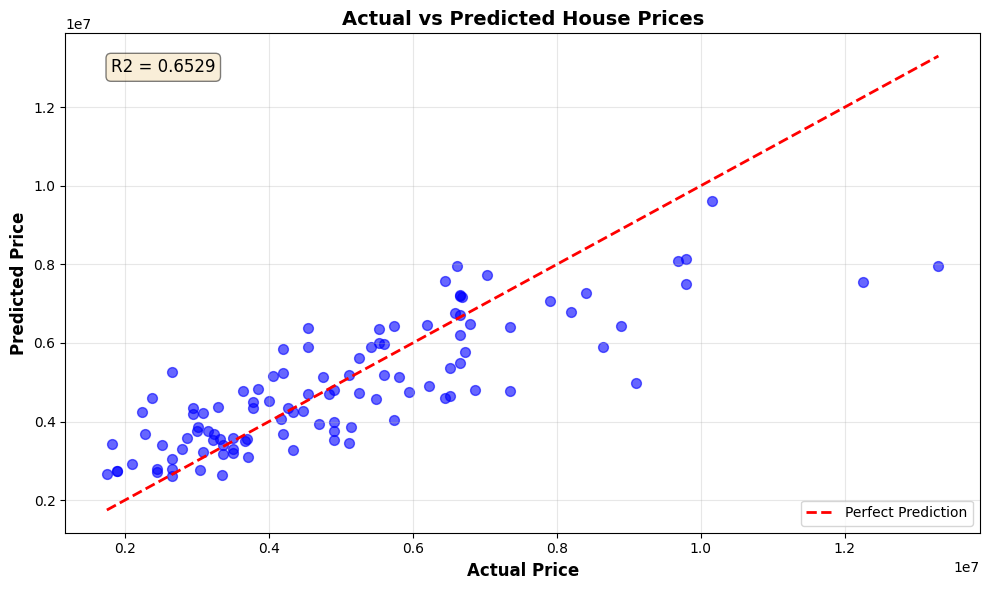

In [20]:

plt.figure(figsize=(10, 6))

plt.scatter(y_test, y_pred, alpha=0.6, color='blue', s=50)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
         'r--', lw=2, label='Perfect Prediction')

plt.xlabel('Actual Price', fontsize=12, fontweight='bold')
plt.ylabel('Predicted Price', fontsize=12, fontweight='bold')
plt.title('Actual vs Predicted House Prices', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)

# Add R2 score to plot
plt.text(0.05, 0.95, f'R2 = {r2:.4f}', transform=plt.gca().transAxes,
         fontsize=12, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

## 3D Scatter Plot using Area, Bedrooms and Price

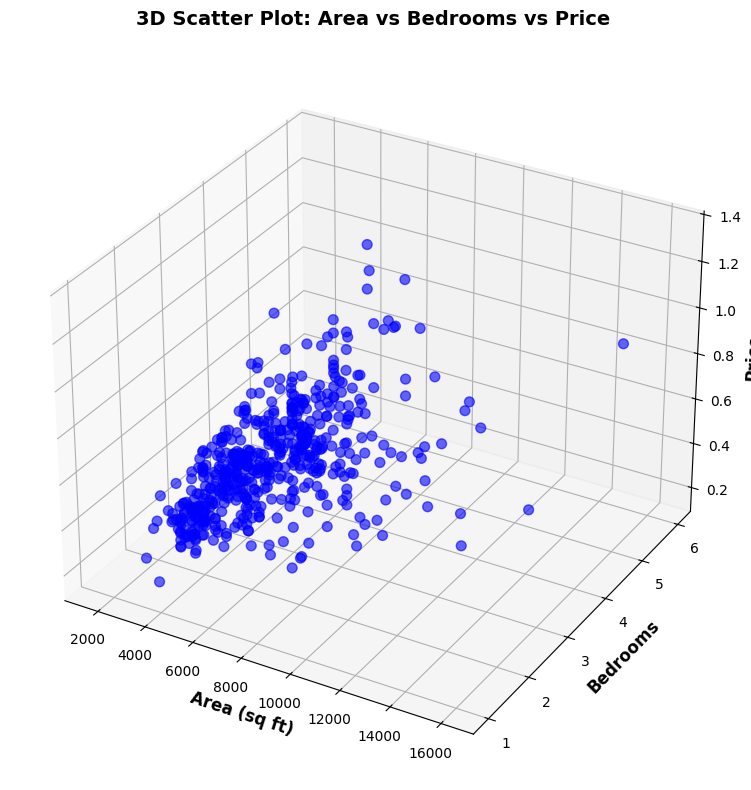

3D plot created successfully!


In [21]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(df['area'], df['bedrooms'], df['price'], 
                    c='blue', marker='o', alpha=0.6, s=50)
ax.set_xlabel('Area (sq ft)', fontsize=12, fontweight='bold')
ax.set_ylabel('Bedrooms', fontsize=12, fontweight='bold')
ax.set_zlabel('Price', fontsize=12, fontweight='bold')
ax.set_title('3D Scatter Plot: Area vs Bedrooms vs Price', 
             fontsize=14, fontweight='bold', pad=20)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("3D plot created successfully!")